# 02. 데이터 정제 — manifest 생성

**이 노트북의 목적**

`01`은 폴더 구조가 말해주는 것만 봤다. 하지만 이미지 데이터셋에는 폴더만 봐서는 절대 알 수 없는
두 가지 문제가 있다.

1. **중복 이미지** — 같은 사진이 여러 장 들어있는 경우. 심하면 클래스를 넘나든다.
2. **라벨 오류** — 신발 사진이 `clothes` 폴더에 들어있는 경우.

둘 다 그냥 두면 성능 숫자 자체를 못 믿게 된다. 특히 중복이 train과 test로 갈라져 들어가면
모델이 시험 문제를 미리 본 셈이 되어 **test 점수가 부풀려진다**(데이터 누수, leakage).

**원칙: 파일을 건드리지 않는다**

폴더 이동이나 삭제는 하지 않는다. 원본은 그대로 두고 **manifest CSV 한 장**으로 관리한다.

| 이유 | 설명 |
|---|---|
| 되돌릴 수 있다 | 실수해도 CSV만 고치면 된다 |
| 근거가 남는다 | 어떤 파일을 왜 뺐는지 `reason` 열에 기록된다 |
| 비교 실험이 쉽다 | `status` 플래그만 바꾸면 정제 전/후를 같은 코드로 돌린다 |

**작업 순서 (순서가 중요하다)**

1. 완전동일 중복 탐지 (MD5)
2. 근접중복 탐지 (dHash → Hamming → 픽셀 검증 → Union-Find)
3. 육안 검토 결과 반영 (오탐 제외, 라벨 정정, 애매·비사진 제외)
4. manifest 생성 및 검증

중복 탐지를 **원본 15,515장 전체**에 대해 먼저 끝낸 뒤 제외를 적용한다. 순서를 바꿔서
"먼저 지우고 그다음 그룹을 만들면" 이미 사라진 파일이 그룹 목록에 남아 그룹이 깨진다.

**출력물**: `outputs/garbage/metrics/manifest.csv`

## 0. 설정

라벨 검토 결과는 팀 내 별도 진단(`1.ipynb` 확신도 기반 후보 추출 → `2.ipynb` 육안 재확인)에서 나온
목록을 그대로 반영한다. 방법론은 `label_error_detection_method.md`에 정리되어 있고, 요약하면
"held-out과 train(2-fold OOF)에서 모델이 **확신하며 틀린** 예측을 전수 추출한 뒤 사람이 직접
이미지를 열어 최종 판정"한 것이다. 이 노트북은 그 **판정 결과**를 코드로 반영하는 단계다.

In [1]:
import os
import json
import hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

OUT = Path("outputs/garbage")
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

index = pd.read_csv(OUT / "metrics" / "index.csv")
classes = sorted(index["label"].unique())

print(f"입력: {len(index):,}행 / {len(classes)}클래스")
print(index["label"].value_counts().to_string())

입력: 15,515행 / 12클래스
label
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607


## 1. 완전동일 중복 탐지 — MD5 해시

15,515장을 픽셀 단위로 서로 비교하면 약 1.2억 쌍(O(n²))이라 현실적이지 않다.
파일 바이트를 **MD5 해시 하나로 요약**하면 같은 해시끼리 묶는 것만으로 O(n)에 끝난다.

여기서 중요한 건 단순히 중복을 세는 게 아니라, **중복이 클래스 경계를 넘나드는지**다.
같은 사진이 서로 다른 두 폴더에 들어있다면 둘 중 하나는 반드시 틀린 라벨이라는 뜻이다.

In [2]:
def file_md5(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


md5_list = [file_md5(p) for p in tqdm(index["path"], desc="MD5 해시 계산")]
index["md5"] = md5_list

md5_to_rows = defaultdict(list)
for i, h in enumerate(md5_list):
    md5_to_rows[h].append(i)

exact_groups = [v for v in md5_to_rows.values() if len(v) > 1]
n_exact_files = sum(len(g) for g in exact_groups)

print(f"완전동일 중복 그룹 수 : {len(exact_groups)}")
print(f"중복에 속한 파일 수   : {n_exact_files}장 "
      f"({100 * n_exact_files / len(index):.2f}%)")
print(f"그룹당 1장만 남길 때 여분: {n_exact_files - len(exact_groups)}장")

MD5 해시 계산:   0%|          | 0/15515 [00:00<?, ?it/s]

완전동일 중복 그룹 수 : 18
중복에 속한 파일 수   : 37장 (0.24%)
그룹당 1장만 남길 때 여분: 19장


In [3]:
# 클래스 경계를 넘나드는 완전동일 중복 = 라벨 모순
cross_class_groups = [g for g in exact_groups
                      if index.loc[g, "label"].nunique() > 1]

print(f"클래스가 서로 다른 완전동일 중복 그룹: {len(cross_class_groups)}건\n")
for g in cross_class_groups:
    print("  ", list(zip(index.loc[g, "label"], index.loc[g, "filename"])))

클래스가 서로 다른 완전동일 중복 그룹: 3건

   [('metal', 'metal459.jpg'), ('white-glass', 'white-glass412.jpg')]
   [('plastic', 'plastic159.jpg'), ('white-glass', 'white-glass129.jpg')]
   [('plastic', 'plastic556.jpg'), ('white-glass', 'white-glass761.jpg')]


### 처리 방침

**같은 클래스 안의 중복** → 그룹당 1장만 남기고 나머지 제외. 정보량이 0이므로 논란의 여지가 없다.

**클래스가 다른 중복** → **양쪽 모두 제외**. 같은 사진에 서로 다른 라벨이 붙어 있으니 최소 하나는
틀렸는데, 어느 쪽이 맞는지 알 방법이 없다. 몇 장 빼는 손해보다 틀린 라벨을 학습에 넣는 손해가 크다.

> 흔히 하는 실수: `df.duplicated(keep="first")`로 처리하면 짝 중 **한 장만** 지워진다.
> 클래스가 다른 쌍에서는 살아남은 한 장이 잘못된 라벨을 달고 학습에 들어간다.
> 아래 코드는 클래스 충돌 그룹을 따로 분기해 전량 제외한다.

In [4]:
cross_ids = {id(g) for g in cross_class_groups}

drop_exact_dup   = []   # 같은 클래스 중복의 여분
drop_label_clash = []   # 클래스 충돌 -> 전량 제외
group_of_exact   = {}   # 완전동일 그룹의 대표(첫 행) 매핑

for g in exact_groups:
    if id(g) in cross_ids:
        drop_label_clash.extend(g)
    else:
        keep, rest = g[0], g[1:]
        drop_exact_dup.extend(rest)
        for r in g:
            group_of_exact[r] = keep

print(f"같은 클래스 중복 여분  : {len(drop_exact_dup)}장")
print(f"클래스 충돌 전량 제외  : {len(drop_label_clash)}장")
print(f"합계 제외 예정         : {len(drop_exact_dup) + len(drop_label_clash)}장")

같은 클래스 중복 여분  : 16장
클래스 충돌 전량 제외  : 6장
합계 제외 예정         : 22장


## 2. 근접중복 탐지

MD5는 바이트가 1비트라도 다르면 못 잡는다. 같은 사진을 리사이즈하거나 다시 JPEG로 저장하면
바이트가 완전히 달라지지만 사람 눈에는 같은 사진이다. 이게 **근접중복(near-duplicate)**이고,
train/test 누수의 실제 원인이다.

**시행착오 기록**: 처음에는 8x8 평균 해시(aHash)를 썼는데 실패했다. 이 데이터셋은 `01`의 샘플
그리드에서 봤듯 흰 배경에 물체 하나가 중앙에 놓인 제품 사진이 많아서, 배터리와 갈색 유리병처럼
**완전히 다른 사진**도 전체 밝기 분포가 비슷하다는 이유만으로 같은 해시로 묶였다. 후보를 픽셀
평균 차이로 한 번 더 걸러도, 배경이 넓고 비슷하면 평균 차이가 작게 나와 여전히 안 걸러졌다.

그래서 3단계로 다시 설계했다.

| 단계 | 기법 | 역할 |
|---|---|---|
| 1 | dHash (16x16, 256bit) | 밝기가 아닌 **구조**(인접 픽셀의 증감)로 요약 |
| 2 | Hamming distance <= 5 | 256비트 중 2% 이내 차이만 후보로 |
| 3 | 32x32 RGB 평균 절대차 < 0.05 | 실제 픽셀 값으로 최종 검증 |

dHash는 "오른쪽 픽셀이 왼쪽보다 밝은가"만 기록하므로 물체의 윤곽 구조에 반응하고,
전체 밝기가 비슷하기만 한 다른 사진은 걸러낸다.

In [5]:
# dHash: 인접 픽셀의 밝기 증감만 기록하는 구조 기반 해시
def dhash_bits(path, hash_size=16):
    img = Image.open(path).convert("L").resize((hash_size + 1, hash_size), Image.LANCZOS)
    arr = np.asarray(img, dtype=np.float32)
    return (arr[:, 1:] > arr[:, :-1]).flatten().astype(np.float32)   # 오른쪽이 더 밝으면 1


HASH_SIZE = 16
bits = np.zeros((len(index), HASH_SIZE * HASH_SIZE), dtype=np.float32)
for i, p in enumerate(tqdm(index["path"], desc="dHash 계산")):
    bits[i] = dhash_bits(p, HASH_SIZE)

print(f"해시 shape: {bits.shape}  (파일 수 x {HASH_SIZE * HASH_SIZE}비트)")

dHash 계산:   0%|          | 0/15515 [00:00<?, ?it/s]

해시 shape: (15515, 256)  (파일 수 x 256비트)


### Hamming distance를 행렬곱으로

0/1 벡터 `a`, `b`의 Hamming distance는 `sum(a) + sum(b) - 2 * (a·b)` 로 쓸 수 있다.
`a·b`는 둘 다 1인 위치의 개수이기 때문이다. 이 항등식을 쓰면 이중 for문(약 1.2억 회) 대신
`(chunk, 256) @ (256, n)` 행렬곱 한 번으로 여러 쌍의 거리를 동시에 구할 수 있다.

In [6]:
row_sums = bits.sum(axis=1)
HAMMING_THRESHOLD = 5      # 256비트 중 5비트(약 2%) 이내면 구조적으로 거의 같은 이미지

n = len(index)
chunk = 1000
hamming_pairs = []

for start in tqdm(range(0, n, chunk), desc="Hamming distance 계산"):
    end = min(start + chunk, n)
    dot = bits[start:end] @ bits.T
    dist = row_sums[start:end, None] + row_sums[None, :] - 2 * dot
    for li in range(end - start):
        i = start + li
        js = np.nonzero(dist[li, i + 1:] <= HAMMING_THRESHOLD)[0] + (i + 1)
        hamming_pairs += [(i, int(j)) for j in js]

print(f"dHash 기준(Hamming <= {HAMMING_THRESHOLD}) 근접중복 후보 쌍: {len(hamming_pairs)}")

Hamming distance 계산:   0%|          | 0/16 [00:00<?, ?it/s]

dHash 기준(Hamming <= 5) 근접중복 후보 쌍: 93


In [7]:
# 구조가 비슷한 후보만 실제 픽셀 값으로 한 번 더 검증 (오탐 제거)
def resized_rgb(path, size=32):
    img = Image.open(path).convert("RGB").resize((size, size), Image.LANCZOS)
    return np.asarray(img, dtype=np.float32) / 255.0


PIXEL_DIFF_THRESHOLD = 0.05     # 32x32 RGB 평균 절대 차이 (0~1 스케일)

rgb_cache = {}
def get_rgb(i):
    if i not in rgb_cache:
        rgb_cache[i] = resized_rgb(index.loc[i, "path"])
    return rgb_cache[i]


verified_pairs = [(i, j) for i, j in tqdm(hamming_pairs, desc="픽셀 값 최종 검증")
                  if np.abs(get_rgb(i) - get_rgb(j)).mean() < PIXEL_DIFF_THRESHOLD]

print(f"구조 + 픽셀 검증을 모두 통과한 쌍: {len(verified_pairs)} / {len(hamming_pairs)}")

픽셀 값 최종 검증:   0%|          | 0/93 [00:00<?, ?it/s]

구조 + 픽셀 검증을 모두 통과한 쌍: 89 / 93


### Union-Find로 쌍을 그룹으로

검증을 통과한 것은 아직 **쌍**이다. A-B가 같고 B-C가 같으면 A-B-C는 한 덩어리여야 하는데,
쌍만으로는 이걸 알 수 없다. Union-Find(서로소 집합)로 연결된 쌍을 하나의 그룹으로 합친다.

이 그룹이 나중에 `03`에서 **같은 split에 통째로 들어가야 하는 단위**가 된다.

In [8]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]   # 경로 압축
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb


uf = UnionFind(len(index))
for i, j in verified_pairs:
    uf.union(i, j)

by_root = defaultdict(list)
for i in range(len(index)):
    by_root[uf.find(i)].append(i)

near_groups = [v for v in by_root.values() if len(v) > 1]

print(f"근접중복 그룹 수      : {len(near_groups)}")
print(f"그룹에 속한 파일 수   : {sum(len(g) for g in near_groups)}장")
print(f"클래스가 다른 그룹 수 : "
      f"{sum(1 for g in near_groups if index.loc[g, 'label'].nunique() > 1)}")

근접중복 그룹 수      : 49
그룹에 속한 파일 수   : 117장
클래스가 다른 그룹 수 : 3


### 육안 확인 — 알고리즘이 놓치는 것

알고리즘은 후보를 좁혀줄 뿐이고 "정말 같은 사진인가"의 최종 판정은 사람이 해야 한다.
위 그룹을 전부 열어본 결과, `trash` 클래스의 7개 그룹은 **서로 다른 칫솔 제품 사진**인데
'흰 배경 + 세로로 선 칫솔'이라는 제품 사진 특유의 구도가 거의 같아서 dHash와 픽셀 검증을
둘 다 통과한 오탐이었다. 나머지 그룹은 반사광 패턴까지 일치하는 진짜 중복이었다.

**대응**: 전역 threshold를 더 조이지 않고 확인된 오탐 7그룹만 명시적으로 제외한다.
threshold를 조이면 진짜 중복(초록 유리병 등)까지 놓칠 위험이 있기 때문이다.
검토자의 판단 근거가 코드에 파일명으로 남는다는 점도 이 방식의 장점이다.

In [9]:
# 육안 확인 결과 오탐으로 판정된 그룹 (서로 다른 칫솔 제품, 구도만 동일)
REVIEWED_FALSE_POSITIVES = [
    {"trash357.jpg", "trash384.jpg", "trash413.jpg", "trash437.jpg",
     "trash468.jpg", "trash486.jpg", "trash544.jpg"},
    {"trash367.jpg", "trash376.jpg", "trash409.jpg", "trash462.jpg",
     "trash473.jpg", "trash514.jpg", "trash547.jpg", "trash653.jpg"},
    {"trash421.jpg", "trash484.jpg", "trash609.jpg", "trash631.jpg"},
    {"trash513.jpg", "trash571.jpg", "trash652.jpg", "trash659.jpg"},
    {"trash360.jpg", "trash488.jpg", "trash593.jpg"},
    {"trash487.jpg", "trash564.jpg"},
    {"trash508.jpg", "trash519.jpg"},
]

def basenames(g):
    return set(index.loc[g, "filename"])

is_fp = [basenames(g) in REVIEWED_FALSE_POSITIVES for g in near_groups]
near_groups = [g for g, fp in zip(near_groups, is_fp) if not fp]

print(f"오탐으로 제외한 그룹: {sum(is_fp)}개")
print(f"최종 근접중복 그룹  : {len(near_groups)}개 "
      f"({sum(len(g) for g in near_groups)}장)")

# MD5로 이미 잡히는 그룹은 제외 대상이라 묶을 필요가 없다.
# 바이트가 서로 다른 그룹만이 실제로 group_id가 필요한 대상이다.
true_near = [g for g in near_groups if index.loc[g, "md5"].nunique() > 1]
print(f"이 중 바이트가 다른 그룹: {len(true_near)}개 "
      f"({sum(len(g) for g in true_near)}장)  <- group_id 부여 대상")

오탐으로 제외한 그룹: 7개
최종 근접중복 그룹  : 42개 (87장)
이 중 바이트가 다른 그룹: 25개 (52장)  <- group_id 부여 대상


## 3. 라벨 검토 결과 반영

별도 진단(`1.ipynb` + `2.ipynb`)에서 확정된 목록이다. 모델의 확신도 기반 자동 추출은 **후보 생성**까지만
하고, "라벨을 옮긴다 / 뺀다"는 최종 판단은 전부 사람이 이미지를 직접 보고 내렸다.

| 카테고리 | 내용 | 처리 |
|---|---|---|
| A-1 | held-out에서 찾은 `clothes` ↔ `shoes` 오류 | 라벨 정정 |
| A-2 | train(OOF)에서 찾은 `clothes` → `shoes` 오류 | 라벨 정정 |
| B | 색상·재질 오류 2건 | 라벨 정정 |
| C | 애매한 경계 사례 3건 | 제외 |
| D | 사진이 아닌 이미지 6건 (클립아트·목업·스케치) | 제외 |

C·D는 합쳐서 9장, 전체의 0.06%다. 성능에는 영향이 없지만 "정답이 존재하지 않는 샘플"과
"실사용 도메인과 다른 이미지"를 학습·평가에 넣지 않는다는 원칙을 지키기 위해 제외하고 기록만 남긴다.

In [10]:
# ── A. 라벨 오류 (정정 대상) ──────────────────────────────────
# A-1: held-out 확신도 기반 진단에서 확정
A1_CLOTHES_TO_SHOES = [
    "clothes3062.jpg", "clothes3330.jpg", "clothes5002.jpg", "clothes2197.jpg",
    "clothes4465.jpg", "clothes1229.jpg", "clothes2272.jpg", "clothes791.jpg",
    "clothes4836.jpg", "clothes5277.jpg", "clothes5181.jpg", "clothes3623.jpg",
    "clothes3807.jpg", "clothes451.jpg",  "clothes2162.jpg", "clothes4329.jpg",
    "clothes255.jpg",  "clothes559.jpg",
]
A1_SHOES_TO_CLOTHES = ["shoes1826.jpg"]        # 반바지 사진 (반대 방향)

# A-2: train 2-fold out-of-fold 진단에서 추가 확정
A2_CLOTHES_TO_SHOES = [
    "clothes2185.jpg", "clothes4319.jpg", "clothes4611.jpg", "clothes5201.jpg",
    "clothes2556.jpg", "clothes1015.jpg", "clothes82.jpg",   "clothes3374.jpg",
    "clothes4466.jpg", "clothes4635.jpg", "clothes2334.jpg", "clothes2654.jpg",
    "clothes4150.jpg", "clothes1312.jpg", "clothes4293.jpg", "clothes2733.jpg",
    "clothes53.jpg",   "clothes3206.jpg", "clothes5045.jpg", "clothes1444.jpg",
    "clothes4495.jpg", "clothes4469.jpg", "clothes3895.jpg", "clothes1582.jpg",
    "clothes3545.jpg",                     # 모델은 metal로 예측했으나 육안상 명백한 장화
]

# B: 색상 / 재질 오류
B_CORRECTIONS = {
    "white-glass704.jpg": "green-glass",    # 짙은 녹색 병
    "paper9.jpg":         "plastic",        # 비닐봉투
}

LABEL_FIX = {}
for f in A1_CLOTHES_TO_SHOES + A2_CLOTHES_TO_SHOES:
    LABEL_FIX[f] = "shoes"
for f in A1_SHOES_TO_CLOTHES:
    LABEL_FIX[f] = "clothes"
LABEL_FIX.update(B_CORRECTIONS)

# ── C, D. 제외 대상 ──────────────────────────────────────────
C_AMBIGUOUS = {
    "white-glass58.jpg": "여러 병이 섞여 있어 판단 애매",
    "shoes379.jpg":      "하이힐 모양 유리 장식품 (형태냐 재질이냐)",
    "clothes526.jpg":    "사진 내용 식별 불가",
}
D_NOT_PHOTO = {
    "trash223.jpg":       "마스크 클립아트",
    "plastic605.jpg":     "플라스틱 병 연필 스케치",
    "white-glass112.jpg": "깨진 유리 클립아트",
    "metal502.jpg":       "캔 목업 템플릿 (워터마크)",
    "green-glass372.jpg": "병 목업 템플릿 (워터마크)",
    "shoes1878.jpg":      "스타일라이즈된 부츠 렌더링",
}

print(f"라벨 정정 대상 : {len(LABEL_FIX)}장 "
      f"(clothes->shoes {len(A1_CLOTHES_TO_SHOES) + len(A2_CLOTHES_TO_SHOES)}, "
      f"shoes->clothes {len(A1_SHOES_TO_CLOTHES)}, 기타 {len(B_CORRECTIONS)})")
print(f"제외 대상      : 애매 {len(C_AMBIGUOUS)} + 비사진 {len(D_NOT_PHOTO)} "
      f"= {len(C_AMBIGUOUS) + len(D_NOT_PHOTO)}장")

# 목록에 오타가 있으면 조용히 무시되므로 실재 여부를 반드시 확인한다
known = set(index["filename"])
missing = [f for f in list(LABEL_FIX) + list(C_AMBIGUOUS) + list(D_NOT_PHOTO)
           if f not in known]
assert not missing, f"index.csv에 없는 파일명: {missing}"
print("\n모든 대상 파일이 index.csv에 존재함 — 확인 완료")

라벨 정정 대상 : 46장 (clothes->shoes 43, shoes->clothes 1, 기타 2)
제외 대상      : 애매 3 + 비사진 6 = 9장

모든 대상 파일이 index.csv에 존재함 — 확인 완료


## 4. manifest 생성

지금까지의 판정을 한 장의 표로 합친다.

| 열 | 의미 |
|---|---|
| `filename`, `path` | 원본 파일 (이동하지 않으므로 경로는 그대로) |
| `orig_label` | 원래 폴더명 |
| `final_label` | 정정 후 라벨. `03` 이후는 이 열만 쓴다 |
| `group_id` | 같은 split에 들어가야 하는 단위. 그룹이 없으면 자기 자신 |
| `status` | `keep` / `drop` |
| `reason` | 왜 그렇게 판정했는지 |

`group_id`는 **제외 여부와 무관하게** 원본 전체 기준으로 먼저 부여한다. 그래야 나중에
`status`를 바꿔가며 정제 전/후를 비교해도 그룹 정의가 흔들리지 않는다.

In [11]:
mf = index[["filename", "path", "label", "md5"]].copy()
mf = mf.rename(columns={"label": "orig_label"})

# ── group_id: 근접중복 그룹 -> 공통 id, 나머지는 자기 자신 ──
group_id = np.array([f"single_{i:05d}" for i in range(len(mf))], dtype=object)
for k, g in enumerate(true_near):
    for r in g:
        group_id[r] = f"nd_{k:03d}"
mf["group_id"] = group_id

# ── final_label ──
mf["final_label"] = mf["orig_label"]
fix_mask = mf["filename"].isin(LABEL_FIX)
mf.loc[fix_mask, "final_label"] = mf.loc[fix_mask, "filename"].map(LABEL_FIX)

# ── status / reason ──
mf["status"] = "keep"
mf["reason"] = ""

def mark(rows, reason):
    mf.loc[rows, "status"] = "drop"
    mf.loc[rows, "reason"] = reason

mark(drop_exact_dup,   "완전동일 중복 (그룹당 1장만 유지)")
mark(drop_label_clash, "완전동일하나 라벨 충돌 (양쪽 제외)")
mark(mf.index[mf["filename"].isin(C_AMBIGUOUS)], "애매한 경계 사례")
mark(mf.index[mf["filename"].isin(D_NOT_PHOTO)], "사진이 아닌 이미지")

mf.loc[fix_mask & (mf["status"] == "keep"), "reason"] = "라벨 정정"

print(mf["status"].value_counts().to_string())
print()
print(mf[mf["status"] == "drop"]["reason"].value_counts().to_string())

status
keep    15484
drop       31

reason
완전동일 중복 (그룹당 1장만 유지)    16
사진이 아닌 이미지               6
완전동일하나 라벨 충돌 (양쪽 제외)     6
애매한 경계 사례                3


In [12]:
# ── 검증: 숫자가 예상과 맞는지 명시적으로 확인 ──
n_total = len(mf)
n_drop  = int((mf["status"] == "drop").sum())
n_keep  = int((mf["status"] == "keep").sum())
n_fix   = int(fix_mask.sum())

expected_drop = (len(drop_exact_dup) + len(drop_label_clash)
                 + len(C_AMBIGUOUS) + len(D_NOT_PHOTO))

print(f"원본        {n_total:,}장")
print(f"제외        {n_drop:,}장  (예상 {expected_drop})")
print(f"최종 유지   {n_keep:,}장")
print(f"라벨 정정   {n_fix}장")

assert n_drop == expected_drop, "제외 수가 예상과 다릅니다"
assert n_keep + n_drop == n_total
assert mf["filename"].nunique() == n_total, "파일명 중복"

# 제외된 파일이 속한 그룹에 살아있는 파일이 남아 있는지 (그룹이 통째로 사라지지 않았는지)
kept = mf[mf["status"] == "keep"]
nd_groups_alive = kept.loc[kept["group_id"].str.startswith("nd_"), "group_id"].nunique()
print(f"\n정제 후에도 살아있는 근접중복 그룹: {nd_groups_alive}개")
print("검증 통과")

원본        15,515장
제외        31장  (예상 31)
최종 유지   15,484장
라벨 정정   46장

정제 후에도 살아있는 근접중복 그룹: 25개
검증 통과


             before  after  diff
battery         945    945     0
biological      985    985     0
brown-glass     607    607     0
cardboard       891    891     0
clothes        5325   5281   -44
green-glass     629    614   -15
metal           769    767    -2
paper          1050   1049    -1
plastic         865    863    -2
shoes          1977   2017    40
trash           697    696    -1
white-glass     775    769    -6

합계 15,515 -> 15,484  (-31)


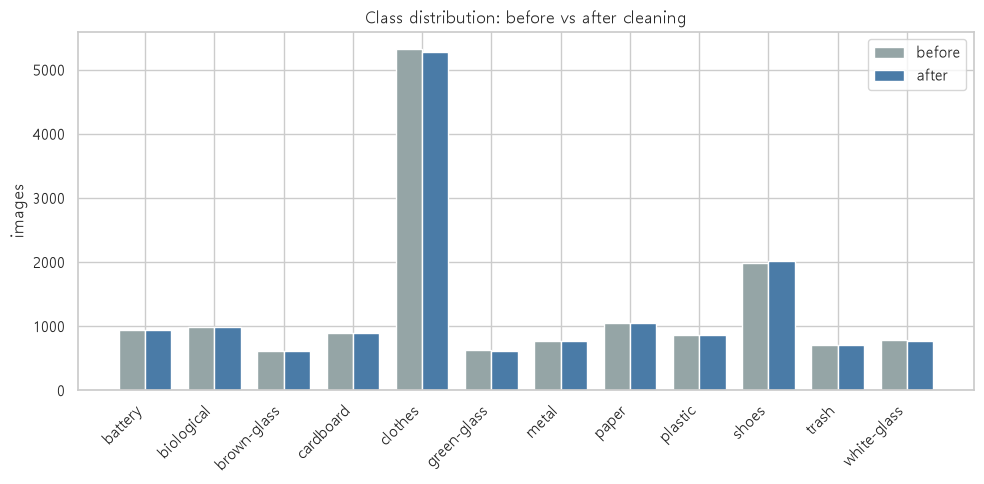

In [13]:
# ── 정제 전/후 클래스 분포 비교 ──
before = mf["orig_label"].value_counts().reindex(classes)
after  = kept["final_label"].value_counts().reindex(classes).fillna(0).astype(int)

comp = pd.DataFrame({"before": before, "after": after})
comp["diff"] = comp["after"] - comp["before"]
print(comp.to_string())
print(f"\n합계 {before.sum():,} -> {after.sum():,}  ({after.sum() - before.sum():+d})")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes))
w = 0.38
ax.bar(x - w / 2, comp["before"], w, label="before", color="#95a5a6")
ax.bar(x + w / 2, comp["after"],  w, label="after",  color="#4a7ba7")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_ylabel("images")
ax.set_title("Class distribution: before vs after cleaning")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "06_clean_effect.png", dpi=150)
plt.show()

`shoes`가 늘고 `clothes`가 줄어든 것이 라벨 정정의 효과다. 나머지 클래스의 감소는 중복 제거분이다.
불균형 비율 자체는 거의 변하지 않는다 — 정제로 불균형이 해결되지는 않으므로 `04`의 불균형 대응
실험은 그대로 필요하다.

In [14]:
cols = ["filename", "path", "orig_label", "final_label",
        "group_id", "status", "reason", "md5"]
mf[cols].to_csv(OUT / "metrics" / "manifest.csv", index=False, encoding="utf-8")

clean_summary = {
    "n_original":          int(n_total),
    "n_exact_dup_groups":  len(exact_groups),
    "n_label_clash_groups": len(cross_class_groups),
    "n_neardup_groups":    len(near_groups),
    "n_neardup_grouped":   len(true_near),
    "n_dropped":           int(n_drop),
    "n_label_fixed":       int(n_fix),
    "n_final":             int(n_keep),
    "hamming_threshold":   HAMMING_THRESHOLD,
    "pixel_diff_threshold": PIXEL_DIFF_THRESHOLD,
}
with open(OUT / "metrics" / "clean_summary.json", "w", encoding="utf-8") as f:
    json.dump(clean_summary, f, ensure_ascii=False, indent=2)

print("manifest.csv 저장:", len(mf), "행")
for k, v in clean_summary.items():
    print(f"  {k:22s} {v}")
print()
print(mf[mf["status"] == "drop"][["filename", "orig_label", "reason"]]
      .head(10).to_string(index=False))

manifest.csv 저장: 15515 행
  n_original             15515
  n_exact_dup_groups     18
  n_label_clash_groups   3
  n_neardup_groups       42
  n_neardup_grouped      25
  n_dropped              31
  n_label_fixed          46
  n_final                15484
  hamming_threshold      5
  pixel_diff_threshold   0.05

          filename  orig_label               reason
   clothes5234.jpg     clothes 완전동일 중복 (그룹당 1장만 유지)
    clothes526.jpg     clothes            애매한 경계 사례
green-glass372.jpg green-glass           사진이 아닌 이미지
green-glass443.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass459.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass461.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass482.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass492.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass517.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)
green-glass530.jpg green-glass 완전동일 중복 (그룹당 1장만 유지)


## 정리

| 항목 | 결과 |
|---|---|
| 완전동일 중복 | 여분 제외 |
| 라벨 충돌 | 클래스가 다른 완전동일 그룹 전량 제외 |
| 근접중복 | 그룹에 `group_id` 부여 (삭제하지 않음) |
| 라벨 오류 | 46장 정정 (대부분 `clothes` → `shoes`) |
| 애매 · 비사진 | 9장 제외 |

**남은 한계 두 가지** (보고서에 명시할 것)

1. **탐지 threshold는 임의값이다.** `Hamming <= 5`, `픽셀차 < 0.05`는 시행착오로 정한 값이지
   최적화된 값이 아니다. 더 느슨하게 잡으면 오탐이 늘고, 조이면 진짜 중복을 놓친다.
2. **라벨 검수 범위가 클래스마다 다르다.** 확신도 기반 진단은 "모델이 확신하며 틀린" 것만
   후보로 올리므로, 모델이 애초에 잘 못 배우는 유형의 오류는 놓친다. `clothes`에 정정이 몰린 것도
   실제로 그 클래스에 오류가 많아서일 수도 있지만, 검수 자체가 그쪽에 집중됐기 때문일 수도 있다.

**다음 단계**: `group_id`가 준비됐으니 이제 같은 사진이 train과 test로 갈라지지 않는 분할을 만든다.
정제 전 방식(단순 stratified)과 정제 후 방식(group-aware)을 **둘 다 저장**해서, `06`에서
데이터 누수의 실제 영향을 숫자로 비교한다.

→ `03_Split.ipynb`